In [1]:
!pip install transformers datasets torch tqdm matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [2]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [3]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import DataCollatorForLanguageModeling

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [5]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Split dataset into train and test
train_texts = dataset["train"]["text"]
test_texts = dataset["test"]["text"]


In [6]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Set pad token

model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)


In [7]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_encodings = dataset["train"].map(tokenize_function, batched=True)
test_encodings = dataset["test"].map(tokenize_function, batched=True)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


In [8]:
train_dataloader = DataLoader(train_encodings, batch_size=8, shuffle=True, collate_fn=data_collator)
test_dataloader = DataLoader(test_encodings, batch_size=8, shuffle=False, collate_fn=data_collator)


In [9]:
!pip install -U accelerate transformers[torch]


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [10]:
pip install -U transformers datasets torch accelerate


Note: you may need to restart the kernel to use updated packages.


In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,  # Increased batch size
    per_device_eval_batch_size=16,
    num_train_epochs=50,
    weight_decay=0.01,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=1000,  # Reduce logging frequency
    fp16=True,  # Enable mixed precision
    gradient_accumulation_steps=4,  # Simulate larger batch
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=test_encodings,
    tokenizer=tokenizer,
    data_collator=data_collator
)


C:\Users\CSIR_prosthetic\AppData\Local\Temp\ipykernel_26068\4115539513.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
trainer.train()


Epoch,Training Loss,Validation Loss
0,No log,3.298883
1,3.198300,3.293911
2,3.198300,3.294918
3,3.005800,3.307289
4,3.005800,3.328508
5,2.865100,3.340988
6,2.747700,3.360753
7,2.747700,3.382522
8,2.634500,3.410345
9,2.634500,3.433120


TrainOutput(global_step=28650, training_loss=2.111125999570517, metrics={'train_runtime': 98233.6938, 'train_samples_per_second': 18.689, 'train_steps_per_second': 0.292, 'total_flos': 4.79514775781376e+17, 'train_loss': 2.111125999570517, 'epoch': 49.99869281045751})

In [16]:
import matplotlib.pyplot as plt

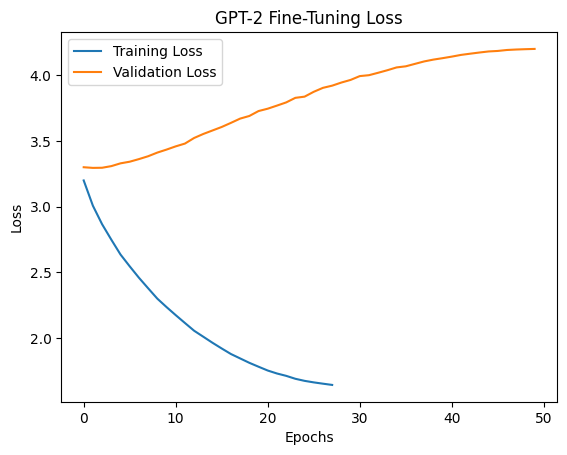

In [17]:
 losses = trainer.state.log_history

train_loss = [x["loss"] for x in losses if "loss" in x]
eval_loss = [x["eval_loss"] for x in losses if "eval_loss" in x]

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GPT-2 Fine-Tuning Loss")
plt.legend()
plt.show()


In [18]:
import math

perplexity = math.exp(eval_loss[-1])
print(f"Model Perplexity: {perplexity:.2f}")


Model Perplexity: 66.64


In [19]:
model.eval()
input_text = "The future of artificial intelligence is"
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
output = model.generate(input_ids, max_length=50, temperature=1.0, do_sample=True)
print("Before Fine-Tuning:", tokenizer.decode(output[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Before Fine-Tuning: The future of artificial intelligence is still beset by the question of how and when humans will use artificial intelligence . AI organizations , by definition , are self @-@ sufficient . They simply do not know when the human level of intelligence has reached its limits


In [21]:
fine_tuned_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
fine_tuned_model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [22]:
fine_tuned_model.save_pretrained('./results')
tokenizer.save_pretrained('./results')


('./results\\tokenizer_config.json',
 './results\\special_tokens_map.json',
 './results\\vocab.json',
 './results\\merges.txt',
 './results\\added_tokens.json')

In [23]:
fine_tuned_model = GPT2LMHeadModel.from_pretrained('./results').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('./results')
fine_tuned_model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [30]:
# Define input text
input_text = "In today's news, a significant event occurred where"

input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

# Create attention mask
attention_mask = (input_ids != tokenizer.pad_token_id).long()

# Generate output
output = fine_tuned_model.generate(input_ids, 
                                   max_length=50, 
                                   temperature=1.0,
                                   do_sample=True,
                                   top_p=0.9,  # Nucleus sampling
                                   attention_mask=attention_mask,
                                   pad_token_id=tokenizer.eos_token_id)



# Decode and print the generated text
print("Generated text: ", tokenizer.decode(output[0], skip_special_tokens=True))


Generated text:  In today's news, a significant event occurred where people began to have an opinion about the importance of an effective policy in a country that is not in war.

On Sept. 7, President Obama called a meeting of Congress to discuss ways to


In [26]:
import torch
from math import exp

# Calculate perplexity
output = fine_tuned_model(input_ids, labels=input_ids)
loss = output.loss
perplexity = exp(loss.item())
print("Perplexity: ", perplexity)


Perplexity:  3505.6536162567


In [31]:
# Define input text
input_text = "In today's news, a significant event occurred where"

input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

# Create attention mask
attention_mask = (input_ids != tokenizer.pad_token_id).long()
output = fine_tuned_model.generate(input_ids, 
                                   max_length=100, 
                                   temperature=0.7, 
                                   do_sample=True,
                                   top_p=0.9,
                                   attention_mask=attention_mask,
                                   pad_token_id=tokenizer.eos_token_id)

# Decode and print the generated text
print("Generated text: ", tokenizer.decode(output[0], skip_special_tokens=True))


Generated text:  In today's news, a significant event occurred where the United States had been involved in a chemical attack on the Syrian town of Khan Shaykhun. The US government has said that the chemical attack was launched from Syria, not Iraq, which is believed to have carried out the attack.

The US-led coalition's "black helicopters" were ordered to assist the Syrian government in the fight against the Islamic State in Iraq and the Levant (ISIL), the United States and its allies said.


In [32]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the fine-tuned model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fine_tuned_model = GPT2LMHeadModel.from_pretrained('./results').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('./results')

# Ensure the model is in evaluation mode
fine_tuned_model.eval()

# Define input text (you can modify this)
input_text = "In a distant future, a new peace treaty was signed between the nations of Mars and Earth. The treaty aimed to"

# Tokenize input text
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

# Create attention mask (to handle padding correctly)
attention_mask = (input_ids != tokenizer.pad_token_id).long()

# Generate output using fine-tuned model
output = fine_tuned_model.generate(input_ids, 
                                   max_length=100,  # You can adjust the length
                                   temperature=1.0,  # Increase randomness for more diverse output
                                   do_sample=True,   # Use sampling
                                   top_p=0.9,        # Nucleus sampling (top-p)
                                   top_k=50,         # Limit to top 50 most likely tokens
                                   attention_mask=attention_mask,  # Include attention mask
                                   pad_token_id=tokenizer.eos_token_id)  # Set pad token ID to EOS token

# Decode and print the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print("Generated text: ", generated_text)


Generated text:  In a distant future, a new peace treaty was signed between the nations of Mars and Earth. The treaty aimed to secure the protection of the planet from all known forms of warfare by establishing a peaceful planet-wide peace treaty, but only the nations could agree to a peace treaty for the next 20 years. With a world divided between the powers, there was little opportunity for peaceful coexistence.

However, with the cooperation of a handful of powerful nations and two major empires, the two major powers


In [35]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the fine-tuned model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fine_tuned_model = GPT2LMHeadModel.from_pretrained('./results').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('./results')

# Ensure the model is in evaluation mode
fine_tuned_model.eval()

# Define input text (you can modify this)
input_text = input_text = "In a distant future, after the Mars-Earth peace treaty was signed, a young diplomat named Sarah discovered a secret plot that could shatter the peace. The plot involved"


# Tokenize input text
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

# Create attention mask (to handle padding correctly)
attention_mask = (input_ids != tokenizer.pad_token_id).long()

# Generate output using fine-tuned model
output = fine_tuned_model.generate(input_ids, 
                                   max_length=100,  # You can adjust the length
                                   temperature=1.0,  # Increase randomness for more diverse output
                                   do_sample=True,   # Use sampling
                                   top_p=0.9,        # Nucleus sampling (top-p)
                                   top_k=50,         # Limit to top 50 most likely tokens
                                   attention_mask=attention_mask,  # Include attention mask
                                   pad_token_id=tokenizer.eos_token_id)  # Set pad token ID to EOS token

# Decode and print the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print("Generated text: ", generated_text)


Generated text:  In a distant future, after the Mars-Earth peace treaty was signed, a young diplomat named Sarah discovered a secret plot that could shatter the peace. The plot involved the use of the U.S. military to infiltrate an ancient civilization's planet-building complex, the Mabuk, through a series of experiments, and take control of a human-run space station known as the S-4-S Enterprise. As the U.S. military began to discover more about her, Sarah decided
